In [3]:
import scarf
import h5py

In [4]:
scarf.__version__

'0.32.3'

In [6]:
# read the .h5ad data. If using other formats and need help converting, go to https://scarf.readthedocs.io/en/latest/vignettes/download_conversion.html
##### Only need to run THIS CMD initially to process the data
reader = scarf.H5adReader(
    h5ad_fn="external_segment_globus_pallidus.h5ad",
    cell_ids_key="CellID",          
    feature_ids_key="_index",        
    feature_name_key="feature_name", 
    matrix_key="X",                     
)
# now write it to the .Zarr format that it wants to be in

writer = scarf.H5adToZarr(
    reader,
    zarr_loc='externalGP.zarr',
    chunk_size=(2000,1000)
)
writer.dump()



INFO: No value provided for assay names. Will use default value: 'RNA'


Reading attributes from group obs:   0%|                                                                      …

Reading attributes from group obsm:   0%|                                                                     …

Reading attributes from group var:   0%|                                                                      …

  0%|                                                                                                         …

In [5]:
ds = scarf.DataStore(
    'externalGP.zarr', # same loco as where you saved the zarr
    nthreads=4,
    min_features_per_cell = 10 # only genes in more than 10 cells will be kept    
)
# reason it is safe to use a scalar factor of 1k even though we have cells with less reads is bc we filter them out in next step

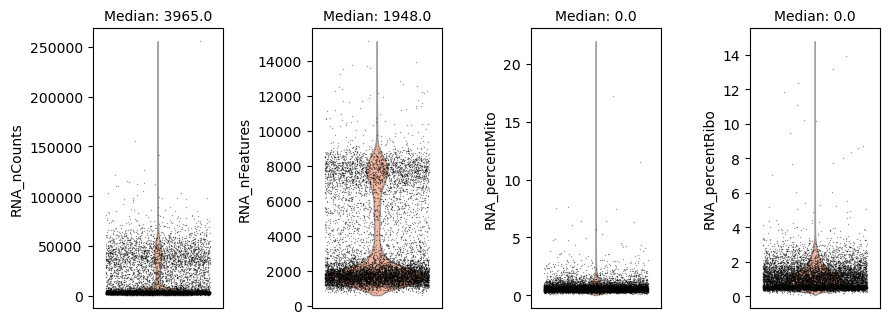

In [11]:
ds.plot_cells_dists(cell_key='I', color='coral')

In [19]:
ds.filter_cells(
    attrs=['RNA_nCounts', 'RNA_nFeatures'],
    highs=[50000, 8500],
    lows=[1000, 500]
)
## since the external segment of the globus pallidus appears to be so weird... I think I will likely do an stringent upper threshold and lower threshold. Not sure if its becuase their is UMI
## duplicates or thats the actual single nucleus morphology here

INFO: 3061 cells flagged for filtering out using attribute RNA_nCounts
INFO: 1650 cells flagged for filtering out using attribute RNA_nFeatures


In [6]:
ds.cells.head()

,I,ids,names,RNA_UMAP1,RNA_UMAP2,RNA_cluster,RNA_leiden_cluster,RNA_nCounts,RNA_nFeatures,RNA_percentMito,...,X_UMAP2,X_tSNE1,X_tSNE2,cell_cycle_score,fraction_mitochondrial,fraction_unspliced,is_primary_data,observation_joinid,total_UMIs,total_genes
0,True,10X393_8:CCCTAACCACGGGCTT,10X393_8:CCCTAACCACGGGCTT,-10.812319,3.452168,7,6,2785.0,1113.0,0.574506,...,7.737397,-27.206246,18.299157,0.000710,0.000710,0.805398,True,7}aZT?-f2(,2816.0,1125.0
1,True,10X393_8:GAGGGATCACCACATA,10X393_8:GAGGGATCACCACATA,-7.735462,-14.247728,3,6,1762.0,967.0,0.510783,...,-0.597485,-30.914347,11.713705,0.003384,0.001692,0.644106,True,aum;Lzw`B$,1773.0,974.0
2,True,10X393_8:TTAGGGTCAACTGCCG,10X393_8:TTAGGGTCAACTGCCG,25.359505,-2.053391,4,3,10412.0,3899.0,1.142912,...,-0.304631,-23.654295,23.684211,0.001437,0.007857,0.761905,True,NylYvfO4b4,10437.0,3916.0
3,True,10X393_7:CCACGTTCAACTGGTT,10X393_7:CCACGTTCAACTGGTT,2.468949,11.737015,27,15,8419.0,3601.0,1.662905,...,8.092102,-26.489448,18.037304,0.001185,0.012201,0.616679,True,9TMF_Viq(e,8442.0,3620.0
4,True,10X419_1:TAGAGTCTCTAGGAAA,10X419_1:TAGAGTCTCTAGGAAA,6.695495,10.234308,10,11,20592.0,5984.0,0.568182,...,10.061797,-23.547928,28.802856,0.001401,0.000145,0.742656,True,aaG!wZb154,20696.0,6032.0


In [7]:
ds.RNA.feats.head()

,I,ids,names,I__hvgs,dropOuts,feature_is_filtered,nCells
0,True,ENSG00000271098,IMMP1LP3,True,50783,False,47
1,True,ENSG00000251026,NIHCOLE,True,50412,False,418
2,True,ENSG00000129451,KLK10,False,50690,False,140
3,True,ENSG00000163568,AIM2,False,49841,False,989
4,True,ENSG00000253327,RAD21-AS1,False,50687,False,143


In [8]:
ds ## takes us down to 47.5k cells total

DataStore has 47568 (50830) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'RNA_UMAP1', 'RNA_UMAP2', 
            'RNA_cluster', 'RNA_leiden_cluster', 'RNA_nCounts', 'RNA_nFeatures', 'RNA_percentMito', 
            'RNA_percentRibo', 'X_UMAP1', 'X_UMAP2', 'X_tSNE1', 'X_tSNE2', 
            'cell_cycle_score', 'fraction_mitochondrial', 'fraction_unspliced', 'is_primary_data', 'observation_joinid', 
            'total_UMIs', 'total_genes'
   RNA assay has 31569 (58232) features and following metadata:
            'I', 'ids', 'names', 'I__hvgs', 'dropOuts', 
            'feature_is_filtered', 'nCells'

INFO: Calculating summary statistics
INFO: Using cached feature stats for cell_key I
INFO: Using existing corrected dispersion values
INFO: Calculating HVGs
INFO: 1990 genes marked as HVGs


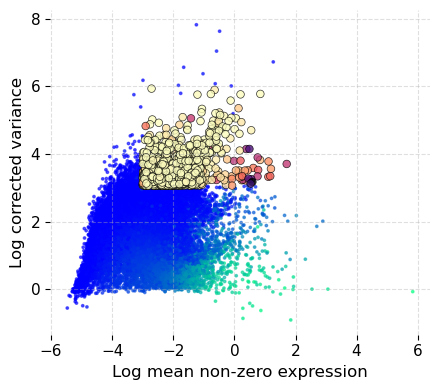

In [9]:
ds.mark_hvgs(
    min_cells=20, # genes found in at least 20 of the cells
    top_n=2000, # means the top 2k highly variable genes
    min_mean=-3,
    max_mean=2,
    max_var=6
)

In [10]:
ds.RNA.feats.head()

,I,ids,names,I__hvgs,dropOuts,feature_is_filtered,nCells,stats_I_avg,stats_I_c_var__200__0.1,stats_I_normed_n,stats_I_normed_tot,stats_I_nz_mean,stats_I_sigmas
0,True,ENSG00000271098,IMMP1LP3,True,50783,False,47,0.000095,9.061598,37.0,4.845531,0.130960,0.000032
1,True,ENSG00000251026,NIHCOLE,True,50412,False,418,0.000770,8.657837,284.0,39.145037,0.137835,0.000349
2,True,ENSG00000129451,KLK10,False,50690,False,140,0.000184,7.751044,68.0,9.332586,0.137244,0.000060
3,True,ENSG00000163568,AIM2,False,49841,False,989,0.001649,6.840544,758.0,83.833196,0.110598,0.000665
4,True,ENSG00000253327,RAD21-AS1,False,50687,False,143,0.000215,6.175565,98.0,10.934750,0.111579,0.000062


In [11]:
ds.make_graph(
    feat_key='hvgs',
    k=11,
    dims=30, ## dims is about the of PCA dimensions
    n_centroids=100
)

INFO: Using existing normalized data with cell key I and feat key I__hvgs
INFO: Using existing loadings for pca with 30 dims
INFO: Using existing ANN index
INFO: using existing kmeans cluster centers
INFO: KNN graph already exists will not recompute.


In [12]:
ds.run_umap(
    n_epochs = 250,
    spread=5,
    min_dist=1,
    parallel=True
)

Training UMAP:   0%|                                                                                          …

	completed  0  /  250 epochs
	completed  25  /  250 epochs
	completed  50  /  250 epochs
	completed  75  /  250 epochs
	completed  100  /  250 epochs
	completed  125  /  250 epochs
	completed  150  /  250 epochs
	completed  175  /  250 epochs
	completed  200  /  250 epochs
	completed  225  /  250 epochs


/opt/anaconda3/lib/python3.12/site-packages/scarf/metadata.py:334: RuntimeWarning: overflow encountered in cast
  a = np.empty(self.N).astype(values.dtype)


In [31]:
ds.cells.head()

,I,ids,names,RNA_UMAP1,RNA_UMAP2,RNA_nCounts,RNA_nFeatures,RNA_percentMito,RNA_percentRibo,X_UMAP1,X_UMAP2,X_tSNE1,X_tSNE2,cell_cycle_score,fraction_mitochondrial,fraction_unspliced,is_primary_data,observation_joinid,total_UMIs,total_genes
0,True,10X393_8:CCCTAACCACGGGCTT,10X393_8:CCCTAACCACGGGCTT,-10.812319,3.452168,2785.0,1113.0,0.574506,0.682226,15.869685,7.737397,-27.206246,18.299157,0.000710,0.000710,0.805398,True,7}aZT?-f2(,2816.0,1125.0
1,True,10X393_8:GAGGGATCACCACATA,10X393_8:GAGGGATCACCACATA,-7.735462,-14.247728,1762.0,967.0,0.510783,1.589103,12.252677,-0.597485,-30.914347,11.713705,0.003384,0.001692,0.644106,True,aum;Lzw`B$,1773.0,974.0
2,True,10X393_8:TTAGGGTCAACTGCCG,10X393_8:TTAGGGTCAACTGCCG,25.359505,-2.053391,10412.0,3899.0,1.142912,0.768344,14.976462,-0.304631,-23.654295,23.684211,0.001437,0.007857,0.761905,True,NylYvfO4b4,10437.0,3916.0
3,True,10X393_7:CCACGTTCAACTGGTT,10X393_7:CCACGTTCAACTGGTT,2.468949,11.737015,8419.0,3601.0,1.662905,1.187790,16.006760,8.092102,-26.489448,18.037304,0.001185,0.012201,0.616679,True,9TMF_Viq(e,8442.0,3620.0
4,True,10X419_1:TAGAGTCTCTAGGAAA,10X419_1:TAGAGTCTCTAGGAAA,6.695495,10.234308,20592.0,5984.0,0.568182,0.796426,16.345463,10.061797,-23.547928,28.802856,0.001401,0.000145,0.742656,True,aaG!wZb154,20696.0,6032.0


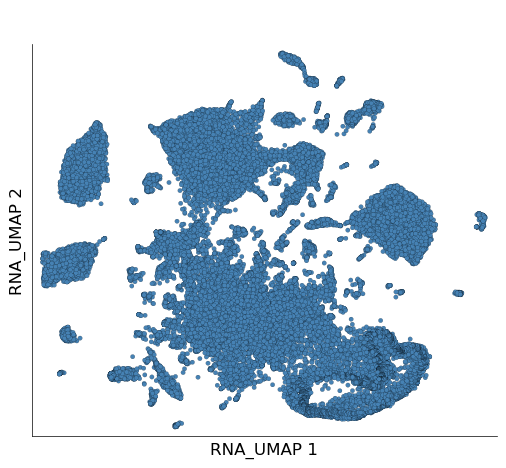

In [32]:
ds.plot_layout(layout_key='RNA_UMAP')

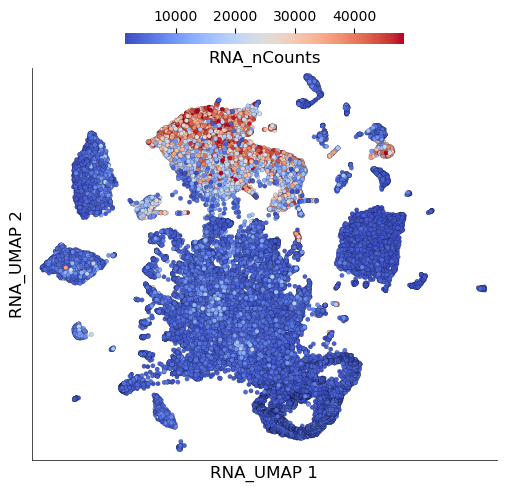

In [13]:
ds.plot_layout(
    layout_key='RNA_UMAP',
    color_by='RNA_nCounts',
    cmap='coolwarm' # visualize data from each column
)

In [51]:
ds.run_leiden_clustering(resolution=.65) # closer to 0 resolution means less clusters, closer to 1 means more clusters

/opt/anaconda3/lib/python3.12/site-packages/scarf/metadata.py:334: RuntimeWarning: invalid value encountered in cast
  a = np.empty(self.N).astype(values.dtype)


/opt/anaconda3/lib/python3.12/site-packages/scarf/plots.py:597: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  centers = df[[x, y, vc]].groupby(vc).median().T


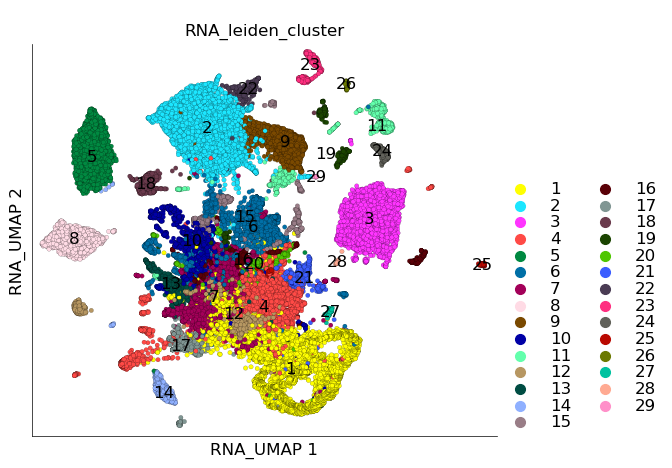

In [14]:
ds.plot_layout(
    layout_key='RNA_UMAP',
    color_by='RNA_leiden_cluster',
)
#savename=None, save_dpi=300

In [15]:
leiden_clusters = ds.cells.to_pandas_dataframe( # output the leiden cluster info into a pds df
    columns=['RNA_leiden_cluster'],
    key='I'
)

In [16]:
leiden_clusters

,RNA_leiden_cluster
0,6
1,6
2,3
3,15
4,11
...,...
50825,16
50826,16
50827,16
50828,9


In [17]:
ds.run_clustering(n_clusters=leiden_clusters.nunique().iloc[0]) ## make it so that the total # of RNA clusters match the # of leiden clusters

INFO: Using existing dendrogram


In [ ]:
ds.run_marker_search(
    group_key='RNA_cluster',
    gene_batch_size=100
)

Finding markers:   0%|                                                                                        …

In [ ]:
ds.plot_marker_heatmap(
    group_key='RNA_cluster',
    topn=5,
    figsize=(6,10)
)

In [ ]:
markers = ds.get_markers(
    group_key='RNA_cluster',
    group_id='1',
    min_score=-1,
    min_frac_exp=-1
)
markers

In [56]:
### test different annotation methods now for cell type, use ur own auto annotater method form linnarson lab or use other methods